# Attempt 1

In [10]:
import random
from collections import defaultdict
import numpy as np

This is a function to track stats for a cube night with 7 people. I make the following assumptions:
1. The length a match of Magic takes is normally distributed (mean = 40 minutes; standard deviation = 8 minutes). You can change this if you want (look at the 2nd line of the code).
2. Matches continue until everyone has played at least 3 matches. The remaining matches conclude and give us the final match time. This means some players are playing more than 3 matches.
3. Players will never play a match against someone they have previously played against. I don't have a completely systematic way to ensure this; therefore, I throw an error if the matchups end up sufficiently 'unresolvable'. If someone has interest, I can explain exactly what I mean by this. However, it only happens about 1/1000 times, so it shouldn't affect our results enough for us to care.

In [ ]:
def round_update(matches_played, x1, x2):
    round_time = random.gauss(mu=40, sigma=15) # Edit this if you want to change the Magic match-length distribution
    matches_played[x1].append(x2)
    matches_played[x2].append(x1)
    return matches_played, round_time
def print_info(ongoing_rounds, current_pairings, remaining_players):
    print(f"Ongoing round times: {ongoing_rounds}")
    print(f"Current round pairings: {current_pairings}")
    print(f"Currently unpaired: {remaining_players}")
    print("")
    return
def append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time):
    round_times.append(new_time)
    ongoing_rounds.append(new_time)
    pairings.append([p1,p2])
    current_pairings.append([p1,p2])
    return round_times, ongoing_rounds, pairings, current_pairings
def count_matches_played(matches_played):
    sum_matches = 0
    for matches in matches_played.values():
        sum_matches += len(matches)
    matches_played = sum_matches/2
    return matches_played
def cube_w_7():
    matches_played = defaultdict(list)
    round_times = []
    ongoing_rounds = []
    pairings = []
    current_pairings = []
    remaining_players = [1,2,3,4,5,6,7]
    random.shuffle(remaining_players)
    
    # Sets up round 1 (i.e. first 3 matches)
    for match in range(3):
        p1 = remaining_players.pop()
        p2 = remaining_players.pop()
        matches_played, round_time = round_update(matches_played, p1, p2)
        round_times.append(round_time)
        ongoing_rounds.append(round_time)
        pairings.append([p1,p2])
        current_pairings.append([p1,p2])
    #print_info(ongoing_rounds, current_pairings, remaining_players)
    
    fewest_matches = 0
    while fewest_matches < 3:
        time_to_finish = min(ongoing_rounds)
        next_to_finish = ongoing_rounds.index(time_to_finish)
        p1 = remaining_players.pop()
        
        if current_pairings[next_to_finish][0] not in matches_played[p1]:
            p2 = current_pairings[next_to_finish][0]
            p2_finish_time = time_to_finish
            remaining_players.append(current_pairings[next_to_finish][1])
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        elif current_pairings[next_to_finish][1] not in matches_played[p1]:
            p2 = current_pairings[next_to_finish][1]
            remaining_players.append(current_pairings[next_to_finish][0])
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        else:
            waiting_ppl = current_pairings.pop(next_to_finish)
            waiting_round_end = ongoing_rounds.pop(next_to_finish)
            remaining_players.extend(waiting_ppl)
            
            time_to_finish = min(ongoing_rounds)
            next_to_finish = ongoing_rounds.index(time_to_finish)
            if current_pairings[next_to_finish][0] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][0]
                remaining_players.append(current_pairings[next_to_finish][1])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif current_pairings[next_to_finish][1] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][1]
                remaining_players.append(current_pairings[next_to_finish][0])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    number_of_matches = count_matches_played(matches_played)
                    return final_time, number_of_matches
                raise TypeError("Unable to create new matchup 1")
    
            p1 = remaining_players.pop()
            if remaining_players[0] not in matches_played[p1]:
                p2 = remaining_players.pop(0)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif remaining_players[1] not in matches_played[p1]:
                p2 = remaining_players.pop(1)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    return final_time, number_of_matches                
                raise TypeError("Unable to create new matchup 2")
    
        player_w_least_matches = min(matches_played.values(), key=len)
        fewest_matches = len(player_w_least_matches)
        
    #print(f"Matches played: {dict(matches_played)}")
    #print(f"Round times: {round_times}")
    #print(f"All round pairings: {pairings}")
    final_time = max(round_times)
    number_of_matches = count_matches_played(matches_played)
    return final_time, number_of_matches

Here is a simulation of 10,000 cube nights with 7 players. I added succussful trials to show that the failure rate is in-fact <1/1000. 

Since people are playing more than 3 matches on average, we account for this by looking at how many matches (on average) a person can complete in 150 minutes. For the set of all game nights $A$, the calculation is:
$$\sum_{i \in A}\frac{2*(\text{number of matches})_i}{(\text{number of players})}*\frac{(150\text{ min})}{(\text{final match time})_i} = \frac{300}{7}\sum_{i \in A}\frac{(\text{number of matches})_i}{(\text{final match time})_i}$$
The multiplication by 2 is because each match consists of 2 people.

In [10]:
final_times_7 = []
number_matches_7 = []
wait_times_7 = []
for _ in range(10000):
    try:
        final_time, number_of_matches = cube_w_7()
        wait_times_7.append(number_of_matches/final_time)
        final_times_7.append(final_time)
        number_matches_7.append(number_of_matches)
    except:
        pass
print(f"Successfull trials: {len(final_times_7)}")
print(f"Average time for the last match to finish: {np.mean(final_times_7)}")
print(f"Average number of matches completed per-person in 150 minutes: {np.mean(wait_times_7)*300/7}")
print(np.mean(number_matches_7))

Successfull trials: 9925
Average time for the last match to finish: 174.84575833405285
Average number of matches completed per-person in 150 minutes: 2.9473874545009404
11.876675062972293


Here is the code for the 8 player cube night, for comparison.

In [38]:
def cube_w_8(mu = 40, sigma = 15):
    final_time = 0
    waiting_time = 0
    for match in range(3):
        r1 = random.gauss(mu=mu, sigma=sigma)
        r2 = random.gauss(mu=mu, sigma=sigma)
        r3 = random.gauss(mu=mu, sigma=sigma)
        r4 = random.gauss(mu=mu, sigma=sigma)
        round_time = max([r1, r2, r3, r4])
        final_time += round_time
        if match != 2:
            waiting_time += 2*(round_time - r1) + 2*(round_time - r2) + 2*(round_time - r3) + 2*(round_time - r4)
    return final_time, waiting_time

The calculation for averagte matches per-person in 150 minutes is simpler here (since there are always 12 matches played):
$$\frac{150*12*2}{8*(\text{avg final time})} $$


In [40]:
final_times_8 = []
waiting_times_8 = []
for _ in range(10000):
    final_time, waiting_time = cube_w_8()
    final_times_8.append(final_time)
    waiting_times_8.append(waiting_time)
mean_final = np.mean(final_times_8)
print(f"Average time for the last match to finish: {mean_final}")
print(f"Average idle time per night: {np.mean(waiting_times_8)}")
print(f"Average number of matches completed per-person in 150 minutes: {2*12*150/mean_final/8}")

Average time for the last match to finish: 166.1320184893417
Average idle time per night: 245.7085513351976
Average number of matches completed per-person in 150 minutes: 2.708689174380133


In conclusion, it seems like matches are being more efficiently played with 8 people, even with all the added waiting times. I played around with the distribution choices a little, but it didn't seem to change that result.

There are issues with 'average downtime per player' (as Andy suggested). Without everyone having at least 3 rounds instead of exactly 3 rounds, the 7 person-pod will have extra wait time added on. We could stop counting wait time once people hit 3 rounds, but what if someone with 3 rounds waits for a while and then plays someone with 2 rounds? This doesn't seem right. What I ended up doing was counting wait time as no longer accruing if someone does not play any more mathces. 

Note: it is a mathematical certainty that someone must play 4 rounds in order for everyone to play at least 3 rounds.

# Attempt 2

Main updates to work on:
1. Clear up metrics confusion
2. Create graph showing how changes in mean/std change results
3. Have an individual-level distribution for each individual
4. Change to 'round-based' so things don't get too out of whack (like Dom proposed)

In [17]:
def round_update(matches_played, x1, x2):
    round_time = random.gauss(mu=40, sigma=15) # Edit this if you want to change the Magic match-length distribution
    matches_played[x1].append(x2)
    matches_played[x2].append(x1)
    return matches_played, round_time
def print_info(ongoing_rounds, current_pairings, remaining_players):
    print(f"Ongoing round times: {ongoing_rounds}")
    print(f"Current round pairings: {current_pairings}")
    print(f"Currently unpaired: {remaining_players}")
    print("")
    return
def append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time):
    round_times.append(new_time)
    ongoing_rounds.append(new_time)
    pairings.append([p1,p2])
    current_pairings.append([p1,p2])
    return round_times, ongoing_rounds, pairings, current_pairings
def count_matches_played(matches_played):
    sum_matches = 0
    for matches in matches_played.values():
        sum_matches += len(matches)
    matches_played = sum_matches/2
    return matches_played
def cube_w_7():
    matches_played = defaultdict(list)
    round_times = []
    ongoing_rounds = []
    pairings = []
    current_pairings = []
    remaining_players = [1,2,3,4,5,6,7]
    random.shuffle(remaining_players)
    count = 0
    
    # Sets up round 1 (i.e. first 3 matches)
    for match in range(3):
        p1 = remaining_players.pop()
        p2 = remaining_players.pop()
        matches_played, round_time = round_update(matches_played, p1, p2)
        round_times, ongoing_rounds, pairings, current_pairings = append_info(
            round_times, ongoing_rounds, pairings, current_pairings, p1, p2, round_time)
    #print_info(ongoing_rounds, current_pairings, remaining_players)
    
    fewest_matches = 0
    while fewest_matches < 3:
        time_to_finish = min(ongoing_rounds)
        next_to_finish = ongoing_rounds.index(time_to_finish)
        p1 = remaining_players.pop()
        
        # Check which of the two finishing players has less matches played
        if len(matches_played[current_pairings[next_to_finish][0]]) < len(matches_played[current_pairings[next_to_finish][1]]):
            preferred_opponent = current_pairings[next_to_finish][0]
            other_opponent = current_pairings[next_to_finish][1]
        else:
            preferred_opponent = current_pairings[next_to_finish][1]
            other_opponent = current_pairings[next_to_finish][0]

        # Try to match with preferred opponent first, then the other opponent (rematch avoidance)
        if preferred_opponent not in matches_played[p1]:
            p2 = preferred_opponent
            remaining_players.append(other_opponent)
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(
                round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        elif other_opponent not in matches_played[p1]:
            p2 = other_opponent
            remaining_players.append(preferred_opponent)
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(
                round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        # If both opponents would result in a rematch, we have to wait for another match to finish
        else:
            count += 1
            waiting_ppl = current_pairings.pop(next_to_finish)
            waiting_round_end = ongoing_rounds.pop(next_to_finish)
            remaining_players.extend(waiting_ppl)
            
            time_to_finish = min(ongoing_rounds)
            next_to_finish = ongoing_rounds.index(time_to_finish)
            if current_pairings[next_to_finish][0] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][0]
                remaining_players.append(current_pairings[next_to_finish][1])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif current_pairings[next_to_finish][1] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][1]
                remaining_players.append(current_pairings[next_to_finish][0])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    number_of_matches = count_matches_played(matches_played)
                    return final_time, number_of_matches
                raise TypeError("Unable to create new matchup 1")
    
            p1 = remaining_players.pop()
            if remaining_players[0] not in matches_played[p1]:
                p2 = remaining_players.pop(0)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif remaining_players[1] not in matches_played[p1]:
                p2 = remaining_players.pop(1)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    return final_time, number_of_matches                
                raise TypeError("Unable to create new matchup 2")
    
        player_w_least_matches = min(matches_played.values(), key=len)
        fewest_matches = len(player_w_least_matches)
        
    #print(f"Matches played: {dict(matches_played)}")
    #print(f"Round times: {round_times}")
    #print(f"All round pairings: {pairings}")
    final_time = max(round_times)
    number_of_matches = count_matches_played(matches_played)
    return count

count = 0
i= 100
for _ in range(i):
    count += cube_w_7()
print(count/i)

TypeError: Unable to create new matchup 2

# Attempt 3

In [2]:
import random
import heapq
import numpy as np

def cube_w_7(mu=40.0, sigma=12.5, target_matches=3, seed=None, verbose=False):
    """
    Simulate the 7-player system you described.

    Returns a dict with:
      - total_time: time when the last match finishes
      - time_all_three: time when everyone has played at least `target_matches`
      - total_idle_time: sum of idle times over all players
      - idle_time_per_player: dict[player] -> idle time
      - matches_per_player: dict[player] -> number of matches played
      - time_of_third: dict[player] -> time they finished their 3rd match
      - opponents: dict[player] -> set of players they faced
    """
    if seed is not None:
        random.seed(seed)

    # Players are labeled 1..7
    players = [1,2,3,4,5,6,7]

    # Who each player has already played
    opponents = {p: set() for p in players}
    matches_per_player = {p: 0 for p in players}
    time_of_third = {p: None for p in players}

    # Idle time accounting
    idle_time = {p: 0.0 for p in players}
    idle_since = {p: 0.0 for p in players}  # everyone idle at t=0

    # Current match id for each player (or None if idle)
    current_match = {p: None for p in players}

    # Event queue: (end_time, match_id, p1, p2, start_time)
    events = []
    match_id_counter = 0
    t = 0.0

    def sample_duration():
        """Draw a strictly positive match duration from N(mu, sigma^2)."""
        d = random.gauss(mu, sigma)
        while d <= 0:
            d = random.gauss(mu, sigma)
        return d

    def start_match(p1, p2, current_time):
        """Start a match between p1 and p2 at current_time."""
        nonlocal match_id_counter
        assert current_match[p1] is None and current_match[p2] is None

        # Close their idle intervals
        for p in (p1, p2):
            idle_time[p] += current_time - idle_since[p]
            idle_since[p] = None

        dur = sample_duration()
        end_time = current_time + dur

        mid = match_id_counter
        match_id_counter += 1

        current_match[p1] = current_match[p2] = mid
        heapq.heappush(events, (end_time, mid, p1, p2, current_time)) # TEMP: first item (end_time) is used for heap ordering, then second item (mid), etc.

        if verbose:
            print(f"t={current_time:.2f}: start match {mid} between P{p1} and P{p2}, "
                  f"ends at {end_time:.2f}")

        return mid, end_time

    # --- Initial random matching: 3 matches + 1 unpaired (7th player) ---
    perm = players[:]
    random.shuffle(perm)
    idle_players = set(players)

    # First 6 players become 3 random pairs
    for k in range(0, 6, 2):
        p1, p2 = perm[k], perm[k + 1]
        start_match(p1, p2, t)
        idle_players.discard(p1)
        idle_players.discard(p2)

    time_all_three = None
    MAX_CONCURRENT = 3
    stop_new_matches = False  # set to True once everyone has >= target_matches

    def schedule_from_idle(current_time, banned=None):
        """
        Try to start additional matches among idle players (not in `banned`).
        Banned players are priority players who cannot be validly matched with any idle players.
        Respects:
          - MAX_CONCURRENT
          - no repeat pairings
          - stop_new_matches flag
        Returns True if at least one match was started.
        """
        nonlocal idle_players
        if stop_new_matches:
            return False

        if banned is None:
            banned = set()

        started_any = False
        # Candidates: idle players who are allowed to be paired now
        candidates = [p for p in idle_players
                      if current_match[p] is None and p not in banned]
        random.shuffle(candidates)
        used = set()

        while len(events) < MAX_CONCURRENT:
            avail = [p for p in candidates if p not in used]
            if len(avail) < 2:
                break

            found_pair = False
            for i in range(len(avail)):
                a = avail[i]
                for j in range(i + 1, len(avail)):
                    b = avail[j]
                    if b in used:
                        continue
                    if b not in opponents[a]:  # no repeat pairing
                        start_match(a, b, current_time)
                        idle_players.discard(a)
                        idle_players.discard(b)
                        used.add(a)
                        used.add(b)
                        started_any = True
                        found_pair = True
                        break
                if found_pair:
                    break

            if not found_pair:
                break

        return started_any

    # --- Main event loop ---
    steps = 0
    while True:
        steps += 1

        # Termination: everyone has at least target_matches and no matches running
        if all(matches_per_player[p] >= target_matches for p in players) and not events:
            total_time = t
            break

        # If there are no matches running but we still need more matches, start from idle
        if not events:
            if verbose:
                print(f"t={t:.2f}: no active matches, scheduling from idle {idle_players}")
            made = schedule_from_idle(t)
            if not made:
                # No legal new matches exist
                total_time = t
                break
            else:
                continue

        # Pop the next finishing match
        end_time, mid, p1, p2, start_time = heapq.heappop(events)
        t = end_time
        if verbose:
            print(f"t={t:.2f}: end match {mid} between P{p1} and P{p2}")

        # Update match stats
        opponents[p1].add(p2)
        opponents[p2].add(p1)
        for p in (p1, p2):
            matches_per_player[p] += 1
            if matches_per_player[p] == target_matches:
                time_of_third[p] = t

        # Mark them idle
        idle_players.update([p1, p2])
        for p in (p1, p2):
            current_match[p] = None
            idle_since[p] = t

        # Check if we just reached "everyone has >= target_matches"
        if time_all_three is None and all(matches_per_player[p] >= target_matches for p in players):
            time_all_three = t
            stop_new_matches = True  # don't start *new* matches after this point

        # --- Scheduling after a match finishes ---

        # "7th unpaired player" = idle player who has been idle the longest
        idle_before = [p for p in idle_players if idle_since[p] < t]  # idle before this finish
        priority_player = min(idle_before, key=lambda p: idle_since[p]) if idle_before else None

        banned = set()

        # Step 1: try to match priority_player with one of the two who just finished
        # (prioritizing which of the two has played fewer matches)
        # (only if we are still allowed to start new matches)
        if priority_player is not None and not stop_new_matches:
            candidates = []
            for q in (p1, p2):
                if q != priority_player and q not in opponents[priority_player]:
                    if current_match[q] is None:
                        candidates.append(q)

            if candidates and len(events) < MAX_CONCURRENT:
                q = min(candidates, key=lambda p: matches_per_player[p])
                start_match(priority_player, q, t)
                idle_players.discard(priority_player)
                idle_players.discard(q)
            else:
                # They already played both finishers; they must wait for another finish,
                # so we don't use them in the generic pairing below.
                banned.add(priority_player)

        # Step 2: fill remaining slots with any other legal idle pairings
        if len(events) < MAX_CONCURRENT:
            schedule_from_idle(t, banned=banned)

        if steps > 10000:
            raise RuntimeError("Too many steps; something went wrong")

    # Close any final idle intervals up to total_time
    #for p in players:
    #    idle_time[p] += total_time - idle_since[p]
    # NOTE: By removing this, I am assuming that once people are done with their final match, they no longer have idle time

    return {
        "total_time": total_time,
        "time_all_three": time_all_three if time_all_three is not None else total_time,
        "total_idle_time": sum(idle_time.values()),
        "idle_time_per_player": idle_time,
        "matches_per_player": matches_per_player,
        "time_of_third": time_of_third,
        "opponents": opponents,
    }



if __name__ != "__main__":
    result = cube_w_7()

    print(f"Total time until last match finishes: {result['total_time']:.2f}")
    print(f"Time until everyone has ≥ 3 matches: {result['time_all_three']:.2f}")
    print(f"Total idle time over all players: {result['total_idle_time']:.2f}")
    print(f"Idle time per player: {result['idle_time_per_player']}")
    print(f"Time each player completed match 3: {result['time_of_third']}")
    print("Matches per player:", result["matches_per_player"])


if __name__ == "__main__":
    
    total_time_list = []
    time_all_three_list = []
    total_idle_time_list = []
    idle_time_per_player_list = []
    time_of_third_list = []
    matches_per_player_list = []
    for _ in range(10000):
        result = cube_w_7()
        total_time_list.append(result['total_time'])
        time_all_three_list.append(result["time_all_three"])
        total_idle_time_list.append(result["total_idle_time"])
        time_of_third_list.append(result["time_of_third"])
        matches_per_player_list.append(result["matches_per_player"])

    print(f"Average total time until last match finishes: {np.mean(total_time_list)}")
    print(f"Average time until everyone has ≥ 3 matches: {np.mean(time_all_three_list)}")
    print(f"Average total idle time over all players: {np.mean(total_idle_time_list)}")
    print(f"Average idle time per player: {np.mean(total_idle_time_list)/7}")



Average total time until last match finishes: 199.62970555381622
Average time until everyone has ≥ 3 matches: 168.7305349406867
Average total idle time over all players: 160.19268688298854
Average idle time per player: 22.884669554712648


In [3]:
def cube_w_8(mu = 35, sigma = 12.5):
    final_time = 0
    idle_time = 0
    for match in range(3):
        r1 = random.gauss(mu=mu, sigma=sigma)
        r2 = random.gauss(mu=mu, sigma=sigma)
        r3 = random.gauss(mu=mu, sigma=sigma)
        r4 = random.gauss(mu=mu, sigma=sigma)
        round_time = max([r1, r2, r3, r4])
        final_time += round_time
        if match != 2:
            idle_time += 2*(round_time - r1) + 2*(round_time - r2) + 2*(round_time - r3) + 2*(round_time - r4)
    return final_time, idle_time

if __name__ != "__main__":
    final_time, idle_time = cube_w_8()
    print(f"Total time until last match finishes: {final_time}")
    print(f"Total idle time over all players: {idle_time}")

if __name__ == "__main__":
    final_times = []
    idle_times = []
    for _ in range(10000):
        final_time, idle_time = cube_w_8()
        final_times.append(final_time)
        idle_times.append(idle_time)
    print(f"Average time for the last match to finish: {np.mean(final_times)}")
    print(f"Average idle time per player: {np.mean(idle_times)/8}")
    

Average time for the last match to finish: 143.54741490696455
Average idle time per player: 25.66616316681643


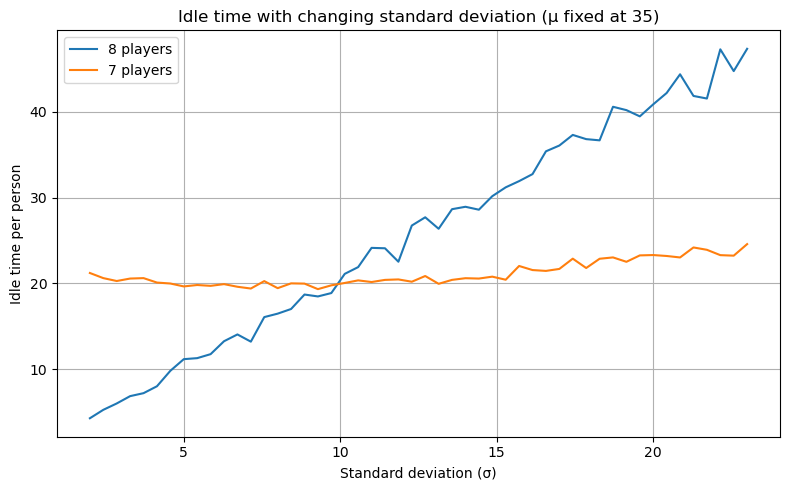

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
mu_fixed = 35

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

stds = np.linspace(2, 23, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for sigma in stds:
    v1_vals = [eff_v1(mu_fixed, sigma)/8 for _ in range(n_runs)]
    v2_vals = [eff_v2(mu_fixed, sigma)/7 for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(stds, scores1, label='8 players')
ax1.plot(stds, scores2, label='7 players')
ax1.set_xlabel("Standard deviation (σ)")
ax1.set_ylabel("Idle time per person")
ax1.set_title(f"Idle time with changing standard deviation (μ fixed at {mu_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()

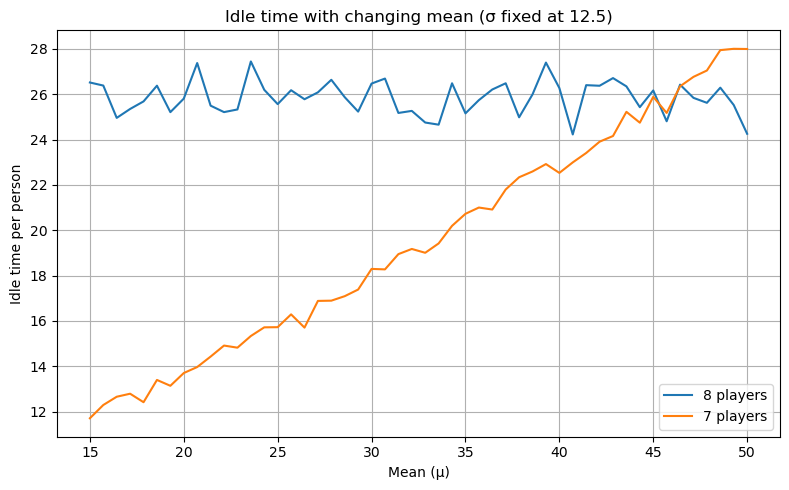

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
sigma_fixed = 12.5 

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

mus = np.linspace(15, 50, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for mu in mus:
    v1_vals = [eff_v1(mu, sigma_fixed)/8 for _ in range(n_runs)]
    v2_vals = [eff_v2(mu, sigma_fixed)/7 for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(mus, scores1, label='8 players')
ax1.plot(mus, scores2, label='7 players')
ax1.set_xlabel("Mean (μ)")
ax1.set_ylabel("Idle time per person")
ax1.set_title(f"Idle time with changing mean (σ fixed at {sigma_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()


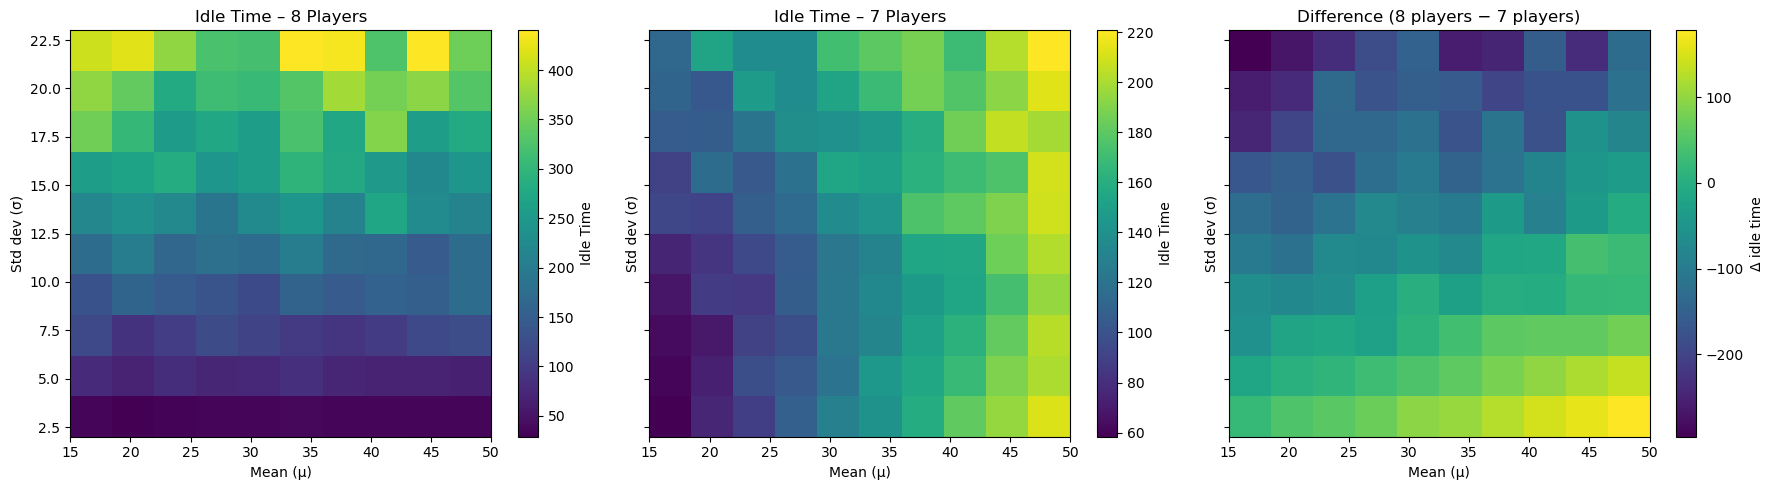

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']


# -------------------------------------------------
# 2. Helper to evaluate over a grid of (mean, std)
# -------------------------------------------------
def evaluate_on_grid(func, means, stds, n_runs=1):
    """
    Evaluate an efficiency function on a grid of (mu, sigma).
    If your function is stochastic, increase n_runs to average over repetitions.
    """
    scores = np.zeros((len(stds), len(means)))

    for i, sigma in enumerate(stds):
        for j, mu in enumerate(means):
            vals = [func(mu, sigma) for _ in range(n_runs)]
            scores[i, j] = np.mean(vals)
    return scores


# -------------------------------------------------
# 3. Choose the range of mean and std you care about
#    (edit these to match your problem)
# -------------------------------------------------
means = np.linspace(15, 50, 10)   # e.g. 20, 25, ..., 60
stds  = np.linspace(2, 23, 10)    # e.g. 5, 7.14, ..., 20

# If the functions are noisy simulations, set n_runs > 1 to average out noise
n_runs = 10

scores1 = evaluate_on_grid(eff_v1, means, stds, n_runs=n_runs)
scores2 = evaluate_on_grid(eff_v2, means, stds, n_runs=n_runs)
diff    = scores2 - scores1      # positive = v2 more efficient than v1


# -------------------------------------------------
# 4. Plot: two heatmaps + difference
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Common extent so x/y are in actual (mu, sigma) units
extent = [means.min(), means.max(), stds.min(), stds.max()]

im1 = axes[0].imshow(scores1, origin='lower', aspect='auto', extent=extent)
axes[0].set_title("Idle Time – 8 Players")
axes[0].set_xlabel("Mean (μ)")
axes[0].set_ylabel("Std dev (σ)")
fig.colorbar(im1, ax=axes[0], label="Idle Time")

im2 = axes[1].imshow(scores2, origin='lower', aspect='auto', extent=extent)
axes[1].set_title("Idle Time – 7 Players")
axes[1].set_xlabel("Mean (μ)")
axes[1].set_ylabel("Std dev (σ)")
fig.colorbar(im2, ax=axes[1], label="Idle Time")

im3 = axes[2].imshow(diff, origin='lower', aspect='auto', extent=extent)
axes[2].set_title("Difference (8 players − 7 players)")
axes[2].set_xlabel("Mean (μ)")
axes[2].set_ylabel("Std dev (σ)")
fig.colorbar(im3, ax=axes[2], label="Δ idle time")

plt.tight_layout()
plt.show()


Super interesting. Idle time in the 8 player draft increases as sigma does, but idle time in the 7 player draft increases as mu does.

# Attempt 4

The only thing I want to add here is individual-level distributions instead of an overall match distribution (hierarchical modeling???). This mimics slow players or people who are playing slow/controlling decks for the night. We can assume that sigma is constant, since people who tend to play at a certain pace will continue to do so with the same variation no matter what the pace is (maybe this is not quite true as mu tends towards 0). However, I would expect slow players to always lead to slow games (in which case summing or max of the two RVs) vs controlling/slow decks which can sometimes be quickly beaten down (so we would need the average of the RVs). I should just make this call though. Lets go with slow players.

I should also add drafting time as an extra factor!!! Someone suggested this on reddit.

In [131]:
import random
import heapq
import numpy as np

def cube_w_7(mu=20.0, sigma=10.0, sigma_p=5.0, target_matches=3, seed=None, verbose=False):
    """
    Simulate the 7-player system you described.

    Returns a dict with:
      - total_time: time when the last match finishes
      - time_all_three: time when everyone has played at least `target_matches`
      - total_idle_time: sum of idle times over all players
      - idle_time_per_player: dict[player] -> idle time
      - matches_per_player: dict[player] -> number of matches played
      - time_of_third: dict[player] -> time they finished their 3rd match
      - opponents: dict[player] -> set of players they faced
    """
    if seed is not None:
        random.seed(seed)

    # Players are labeled 1..7
    players = [1,2,3,4,5,6,7]
    
    # Each player has a speed factor
    player_speed = {p: random.gauss(mu, sigma_p) for p in players}

    # Who each player has already played
    opponents = {p: set() for p in players}
    matches_per_player = {p: 0 for p in players}
    time_of_third = {p: None for p in players}

    # Idle time accounting
    idle_time = {p: 0.0 for p in players}
    idle_since = {p: 0.0 for p in players}  # everyone idle at t=0

    # Current match id for each player (or None if idle)
    current_match = {p: None for p in players}

    # Event queue: (end_time, match_id, p1, p2, start_time)
    events = []
    match_id_counter = 0
    t = 0.0

    def sample_duration(p1, p2):
        """Draw a positive match duration from N(players_mu, sigma^2)."""
        d1 = max(random.gauss(player_speed[p1], sigma), 0)
        d2 = max(random.gauss(player_speed[p2], sigma), 0)
        d = d1 + d2
        return d

    def start_match(p1, p2, current_time):
        """Start a match between p1 and p2 at current_time."""
        nonlocal match_id_counter
        assert current_match[p1] is None and current_match[p2] is None

        # Close their idle intervals
        for p in (p1, p2):
            idle_time[p] += current_time - idle_since[p]
            idle_since[p] = None

        dur = sample_duration(p1, p2)
        end_time = current_time + dur

        mid = match_id_counter
        match_id_counter += 1

        current_match[p1] = current_match[p2] = mid
        heapq.heappush(events, (end_time, mid, p1, p2, current_time))

        if verbose:
            print(f"t={current_time:.2f}: start match {mid} between P{p1} and P{p2}, "
                  f"ends at {end_time:.2f}")

        return mid, end_time

    # --- Initial random matching: 3 matches + 1 unpaired (7th player) ---
    perm = players[:]
    random.shuffle(perm)
    idle_players = set(players)

    # First 6 players become 3 random pairs
    for k in range(0, 6, 2):
        p1, p2 = perm[k], perm[k + 1]
        start_match(p1, p2, t)
        idle_players.discard(p1)
        idle_players.discard(p2)

    time_all_three = None
    MAX_CONCURRENT = 3
    stop_new_matches = False  # set to True once everyone has >= target_matches

    def schedule_from_idle(current_time, banned=None):
        """
        Try to start additional matches among idle players (not in `banned`).
        Banned players are priority players who cannot be validly matched with any idle players.
        Respects:
          - MAX_CONCURRENT
          - no repeat pairings
          - stop_new_matches flag
        Returns True if at least one match was started.
        """
        nonlocal idle_players
        if stop_new_matches:
            return False

        if banned is None:
            banned = set()

        started_any = False
        # Candidates: idle players who are allowed to be paired now
        candidates = [p for p in idle_players
                      if current_match[p] is None and p not in banned]
        random.shuffle(candidates)
        used = set()

        while len(events) < MAX_CONCURRENT:
            avail = [p for p in candidates if p not in used]
            if len(avail) < 2:
                break

            found_pair = False
            for i in range(len(avail)):
                a = avail[i]
                for j in range(i + 1, len(avail)):
                    b = avail[j]
                    if b in used:
                        continue
                    if b not in opponents[a]:  # no repeat pairing
                        start_match(a, b, current_time)
                        idle_players.discard(a)
                        idle_players.discard(b)
                        used.add(a)
                        used.add(b)
                        started_any = True
                        found_pair = True
                        break
                if found_pair:
                    break

            if not found_pair:
                break

        return started_any

    # --- Main event loop ---
    steps = 0
    while True:
        steps += 1

        # Termination: everyone has at least target_matches and no matches running
        if all(matches_per_player[p] >= target_matches for p in players) and not events:
            total_time = t
            break

        # If there are no matches running but we still need more matches, start from idle
        if not events:
            if verbose:
                print(f"t={t:.2f}: no active matches, scheduling from idle {idle_players}")
            made = schedule_from_idle(t)
            if not made:
                # No legal new matches exist
                total_time = t
                break
            else:
                continue

        # Pop the next finishing match
        end_time, mid, p1, p2, start_time = heapq.heappop(events)
        t = end_time
        if verbose:
            print(f"t={t:.2f}: end match {mid} between P{p1} and P{p2}")

        # Update match stats
        opponents[p1].add(p2)
        opponents[p2].add(p1)
        for p in (p1, p2):
            matches_per_player[p] += 1
            if matches_per_player[p] == target_matches:
                time_of_third[p] = t

        # Mark them idle
        idle_players.update([p1, p2])
        for p in (p1, p2):
            current_match[p] = None
            idle_since[p] = t

        # Check if we just reached "everyone has >= target_matches"
        if time_all_three is None and all(matches_per_player[p] >= target_matches for p in players):
            time_all_three = t
            stop_new_matches = True  # don't start *new* matches after this point

        # --- Scheduling after a match finishes ---

        # "7th unpaired player" = idle player who has been idle the longest
        idle_before = [p for p in idle_players if idle_since[p] < t]  # idle before this finish
        priority_player = min(idle_before, key=lambda p: idle_since[p]) if idle_before else None

        banned = set()

        # Step 1: try to match priority_player with one of the two who just finished
        # (prioritizing which of the two has played fewer matches)
        # (only if we are still allowed to start new matches)
        if priority_player is not None and not stop_new_matches:
            candidates = []
            for q in (p1, p2):
                if q != priority_player and q not in opponents[priority_player]:
                    if current_match[q] is None:
                        candidates.append(q)

            if candidates and len(events) < MAX_CONCURRENT:
                q = min(candidates, key=lambda p: matches_per_player[p])
                start_match(priority_player, q, t)
                idle_players.discard(priority_player)
                idle_players.discard(q)
            else:
                # They already played both finishers; they must wait for another finish,
                # so we don't use them in the generic pairing below.
                banned.add(priority_player)

        # Step 2: fill remaining slots with any other legal idle pairings
        if len(events) < MAX_CONCURRENT:
            schedule_from_idle(t, banned=banned)

        if steps > 10000:
            raise RuntimeError("Too many steps; something went wrong")

    return {
        "total_time": total_time,
        "time_all_three": time_all_three if time_all_three is not None else total_time,
        "total_idle_time": sum(idle_time.values()),
        "idle_time_per_player": idle_time,
        "matches_per_player": matches_per_player,
        "time_of_third": time_of_third,
        "opponents": opponents,
    }



if __name__ == "__main__":
    result = cube_w_7()

    print(f"Total time until last match finishes: {result['total_time']:.2f}")
    print(f"Time until everyone has ≥ 3 matches: {result['time_all_three']:.2f}")
    print(f"Total idle time over all players: {result['total_idle_time']:.2f}")
    print(f"Idle time per player: {result["idle_time_per_player"]}")
    print(f"Time each player completed match 3: {result['time_of_third']}")
    print("Matches per player:", result["matches_per_player"])


if __name__ != "__main__":
    
    total_time_list = []
    time_all_three_list = []
    total_idle_time_list = []
    idle_time_per_player_list = []
    time_of_third_list = []
    matches_per_player_list = []
    for _ in range(1000):
        result = cube_w_7()
        total_time_list.append(result['total_time'])
        time_all_three_list.append(result["time_all_three"])
        total_idle_time_list.append(result["total_idle_time"])
        time_of_third_list.append(result["time_of_third"])
        matches_per_player_list.append(result["matches_per_player"])

    print(f"Average total time until last match finishes: {np.mean(total_time_list)}")
    print(f"Average time until everyone has ≥ 3 matches: {np.mean(time_all_three_list)}")
    print(f"Average total idle time over all players: {np.mean(total_idle_time_list)}")
    print(f"Average idle time per player: {np.mean(total_idle_time_list)}")



Total time until last match finishes: 207.69
Time until everyone has ≥ 3 matches: 181.53
Total idle time over all players: 213.98
Idle time per player: {1: 13.489547178694991, 2: 47.5255158116999, 3: 47.69697664769343, 4: 35.47172058779129, 5: 16.649652242674925, 6: 38.76114676949381, 7: 14.386775503106648}
Time each player completed match 3: {1: 122.46419847256605, 2: 84.50680616789668, 3: 118.80192109257587, 4: 181.53481254464054, 5: 181.53481254464054, 6: 79.17603855295016, 7: 122.46419847256605}
Matches per player: {1: 5, 2: 5, 3: 5, 4: 3, 5: 3, 6: 5, 7: 4}


In [ ]:
def cube_w_8(mu=20.0, sigma=10.0, sigma_p=5.0, seed=None):
    
    if seed is not None:
        random.seed(seed)
        
    final_time = 0
    idle_time = 0
    # Players are labeled 1 to 8
    players = [1,2,3,4,5,6,7,8]
    # Matchups - unique up to isomorphism
    matches = [[1,2], [3,4], [5,6], [7,8], [1,3], [2,4], [5,7], [6,8], [1,5], [2,6], [3,7], [4,8]]
    
    # Each player has a speed factor
    player_speed = {p: random.gauss(mu, sigma_p) for p in players}

    for round in range(0, 12, 4):
        matchups = matches[round:round+4]
        match_times = []
        
        # Simulate each match in the round
        for match in matchups:
            p1, p2 = match
            d1 = max(random.gauss(player_speed[p1], sigma), 0)
            d2 = max(random.gauss(player_speed[p2], sigma), 0)
            match_time = d1 + d2
            match_times.append(match_time)
        final_time += max(match_times)
        
        # Calculate idle time for players in this round (only if not the last round)
        if round != 8:
            idle_time += 2*(max(match_times) - match_times[0]) + 2*(max(match_times) - match_times[1]) +\
                         2*(max(match_times) - match_times[2]) + 2*(max(match_times) - match_times[3])
    return final_time, idle_time

if __name__ != "__main__":
    final_time, idle_time = cube_w_8()
    print(f"Total time until last match finishes: {final_time}")
    print(f"Total idle time over all players: {idle_time}")


Total time until last match finishes: 147.97738386516258
Total idle time over all players: 274.2547139542615


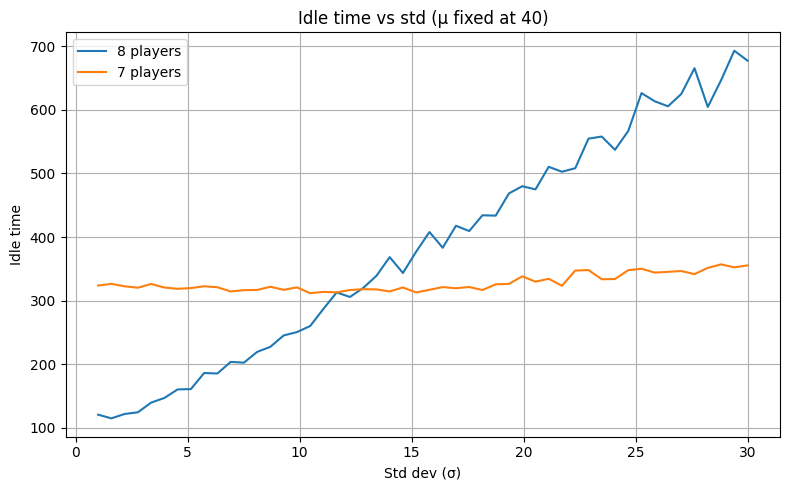

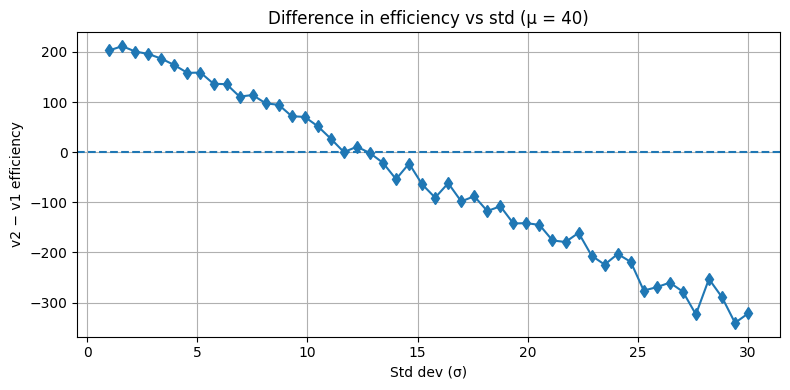

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
mu_fixed = 40 

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

stds = np.linspace(1, 30, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for sigma in stds:
    v1_vals = [eff_v1(mu_fixed, sigma) for _ in range(n_runs)]
    v2_vals = [eff_v2(mu_fixed, sigma) for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(stds, scores1, label='8 players')
ax1.plot(stds, scores2, label='7 players')
ax1.set_xlabel("Std dev (σ)")
ax1.set_ylabel("Idle time")
ax1.set_title(f"Idle time vs std (μ fixed at {mu_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 4. Optional: separate plot for the difference
# -----------------------------------------
fig, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(stds, diff, marker='d')
ax2.axhline(0, linestyle='--')
ax2.set_xlabel("Std dev (σ)")
ax2.set_ylabel("v2 − v1 efficiency")
ax2.set_title(f"Difference in efficiency vs std (μ = {mu_fixed})")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [187]:
def drafting_time(players = 8, cards_in_pack = 15, packs = 3):
    final_time = 0
    for pack in range(packs):
        for card in range(cards_in_pack):
            pick_times = {p:0 for p in range(players)}
            for t in range(players):
                pick_times[t] += max(random.gauss(3*(cards_in_pack-card) + 3*pack, 7), 0)
            final_time += max(pick_times.values())
    final_minutes = final_time / 60
    return final_minutes
drafting_8 = []
drafting_7 = []
for _ in range(1000):
    drafting_8.append(drafting_time(players=8))
    drafting_7.append(drafting_time(players=7))
print(f"Average drafting time for 8 players: {np.mean(drafting_8)} minutes")
print(f"Average drafting time for 7 players: {np.mean(drafting_7)} minutes")

Average drafting time for 8 players: 27.719407750423684 minutes
Average drafting time for 7 players: 27.343070593842388 minutes


# Animation

In [13]:
import random
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation, PillowWriter
import random

# ---------- 8 Person Cube Night: Adapted for GIF ----------


def cube_w_8(mu=38, sigma=10, seed=None):
    """
    8-player cube with 3 rounds, 4 matches per round (all concurrent).

    Returns
    -------
    final_time : float
        Same as your original function.
    idle_time : float
        Same as your original function.
    matches : list of dict
        Each dict has keys: id, p1, p2, start, end, table
        and is compatible with create_tournament_video().
    """
    if seed is not None:
        random.seed(seed)

    # 8 players, fixed pairings each round so we don't consume extra RNG calls
    players = list(range(1, 9))
    pairs = [(1, 2), (3, 4), (5, 6), (7, 8)]

    matches = []
    final_time = 0.0
    idle_time = 0.0
    match_id = 0

    for match_round in range(3):
        r1 = random.gauss(mu=mu, sigma=sigma)
        r2 = random.gauss(mu=mu, sigma=sigma)
        r3 = random.gauss(mu=mu, sigma=sigma)
        r4 = random.gauss(mu=mu, sigma=sigma)
        round_durations = [r1, r2, r3, r4]
        round_time = max(round_durations)

        # All 4 matches in this round start at the same time
        start_time = final_time

        # Build the 4 match records for this round
        for table_idx, (p1, p2) in enumerate(pairs):
            dur = round_durations[table_idx]
            matches.append(
                {
                    "id": match_id,
                    "p1": p1,
                    "p2": p2,
                    "start": start_time,
                    "end": start_time + dur,
                    "table": table_idx,  # 0, 1, 2, 3
                }
            )
            match_id += 1

        # Your original 'final_time' logic
        final_time += round_time

        # Your original 'idle_time' logic (no idle after last round)
        if match_round != 2:
            idle_time += (
                2 * (round_time - r1)
                + 2 * (round_time - r2)
                + 2 * (round_time - r3)
                + 2 * (round_time - r4)
            )

    return final_time, idle_time, matches


# ---------- 7 Person Cube Night: Adapted for GIF ----------

def simulate_tournament(mu=38.0, sigma=10.0, target_matches=3, seed=None):
    """
    Simulate a 7-player tournament with:
      - Normal(mu, sigma) match times (truncated at > 0)
      - At most 3 matches concurrently
      - No pair of players ever meets twice
      - Priority for the longest-waiting idle player after each match

    Returns:
      {
        "matches": [
            {"id", "p1", "p2", "start", "end", "table"},
            ...
        ],
        "total_time": time of last match finishing,
        "time_all_three": earliest time when everyone has >= target_matches matches
      }
    """
    if seed is not None:
        random.seed(seed)

    players = list(range(1, 8))
    opponents = {p: set() for p in players}
    matches_played = {p: 0 for p in players}

    events = []          # priority queue: (end_time, match_id, p1, p2, start_time)
    match_history = []   # list of match dicts
    match_table = {}     # match_id -> table index

    MAX_CONCURRENT = 3
    table_slots = [None] * MAX_CONCURRENT  # which match is on each table
    idle_players = set(players)
    idle_since = {p: 0.0 for p in players}  # when each player last became idle
    t = 0.0
    match_id_counter = 0
    stop_new_matches = False

    def sample_duration():
        """Strictly positive sample from N(mu, sigma)."""
        while True:
            d = random.gauss(mu, sigma)
            if d > 0:
                return d

    def get_free_table():
        for idx, mid in enumerate(table_slots):
            if mid is None:
                return idx
        return None

    def start_match(p1, p2, current_time):
        """Start a match between p1 and p2 at current_time."""
        nonlocal match_id_counter

        table_idx = get_free_table()
        if table_idx is None:
            raise RuntimeError("Tried to start a match with no free table")

        mid = match_id_counter
        match_id_counter += 1

        dur = sample_duration()
        end_time = current_time + dur

        table_slots[table_idx] = mid
        idle_players.discard(p1)
        idle_players.discard(p2)

        match = {
            "id": mid,
            "p1": p1,
            "p2": p2,
            "start": current_time,
            "end": end_time,
            "table": table_idx,
        }
        match_history.append(match)
        match_table[mid] = table_idx

        heapq.heappush(events, (end_time, mid, p1, p2, current_time))

    def schedule_from_idle(current_time, banned=None):
        """
        Fill free tables with matches among idle players (excluding `banned`).
        Obeys:
          - no repeated opponents
          - stop_new_matches flag
        """
        if stop_new_matches:
            return False
        if banned is None:
            banned = set()

        started_any = False
        while len(events) < MAX_CONCURRENT:
            avail = [p for p in idle_players if p not in banned]
            if len(avail) < 2:
                break

            pair_found = False
            for i in range(len(avail)):
                a = avail[i]
                for j in range(i + 1, len(avail)):
                    b = avail[j]
                    if b not in opponents[a]:
                        start_match(a, b, current_time)
                        pair_found = True
                        started_any = True
                        break
                if pair_found:
                    break
            if not pair_found:
                break

        return started_any

    # --- Initial random pairing at t = 0: 3 matches, 1 idle player ---
    perm = players[:]
    random.shuffle(perm)
    for k in range(0, 6, 2):
        p1, p2 = perm[k], perm[k + 1]
        start_match(p1, p2, t)

    total_time = None
    time_all_three = None
    steps = 0

    # --- Event loop ---
    while True:
        steps += 1

        # If nothing is running, either we're done or need to schedule from idle
        if not events:
            if all(matches_played[p] >= target_matches for p in players):
                total_time = t
                break
            else:
                made = schedule_from_idle(t)
                if not made:
                    total_time = t  # no legal matches remain
                    break
                continue

        end_time, mid, p1, p2, start_time = heapq.heappop(events)
        t = end_time

        # Clear table
        table_idx = match_table[mid]
        table_slots[table_idx] = None

        # Update stats
        opponents[p1].add(p2)
        opponents[p2].add(p1)
        matches_played[p1] += 1
        matches_played[p2] += 1

        # Both players become idle at time t
        for p in (p1, p2):
            idle_players.add(p)
            idle_since[p] = t

        # First time everybody has >= target_matches
        if time_all_three is None and all(matches_played[p] >= target_matches for p in players):
            time_all_three = t
            stop_new_matches = True  # don't start *new* matches after this

        # Scheduling after a match finishes
        banned = set()

        # "7th unpaired" = idle player who's been idle the longest (idle_since is smallest)
        idle_before = [p for p in idle_players if idle_since[p] < t]
        priority_player = min(idle_before, key=lambda p: idle_since[p]) if idle_before else None

        # Step 1: try to match priority player with one of the two who just finished
        if priority_player is not None and not stop_new_matches and len(events) < MAX_CONCURRENT:
            candidates = []
            for q in (p1, p2):
                if q != priority_player and q in idle_players and q not in opponents[priority_player]:
                    candidates.append(q)

            if candidates:
                q = random.choice(candidates)
                start_match(priority_player, q, t)
            else:
                # They have already played both finishers; they must wait for another match to finish
                banned.add(priority_player)

        # Step 2: fill any remaining free tables with other idle-idle pairs
        if len(events) < MAX_CONCURRENT:
            schedule_from_idle(t, banned=banned)

        # Safety guard
        if steps > 10000:
            raise RuntimeError("Too many steps; potential infinite loop.")

    if total_time is None:
        total_time = t

    return {
        "matches": match_history,
        "total_time": total_time,
        "time_all_three": time_all_three,
    }


# ---------- Idle-time and per-player statistics ----------

def build_player_timelines(matches, players):
    """
    For each player:
      - sort their matches by start time
      - build idle segments *only* when they will play again in the future
        (so no idle time after their last match)
    """
    matches_by_player = {p: [] for p in players}
    for m in matches:
        matches_by_player[m["p1"]].append(m)
        matches_by_player[m["p2"]].append(m)
    for p in players:
        matches_by_player[p].sort(key=lambda m: m["start"])

    idle_segments = {p: [] for p in players}
    last_end = {}

    for p in players:
        mlist = matches_by_player[p]
        if not mlist:
            last_end[p] = 0.0
            continue

        intervals = [(m["start"], m["end"]) for m in mlist]
        first_start = intervals[0][0]

        # Idle from t=0 to first match start (if first match isn't at t=0)
        if first_start > 0:
            idle_segments[p].append((0.0, first_start))

        # Idle between matches
        for (s1, e1), (s2, e2) in zip(intervals, intervals[1:]):
            if s2 > e1:
                idle_segments[p].append((e1, s2))

        # We intentionally do NOT add [last_end, total_time] here
        # to stop accruing wait time after their final match.
        last_end[p] = max(e for (s, e) in intervals)

    return matches_by_player, idle_segments, last_end


def idle_time_at(p, t, idle_segments):
    """Idle time accumulated by player p up to time t, ignoring post-last-match idle."""
    total = 0.0
    for a, b in idle_segments[p]:
        if t <= a:
            continue
        elif t >= b:
            total += b - a
        else:
            total += t - a
    return total


def matches_finished_at(p, t, matches_by_player):
    """Number of matches player p has finished by time t."""
    return sum(1 for m in matches_by_player[p] if m["end"] <= t)


def current_match_at(p, t, matches_by_player):
    """Return the match dict player p is currently in at time t, or None."""
    for m in matches_by_player[p]:
        if m["start"] <= t < m["end"]:
            return m
    return None


def compute_summary_stats(matches, players):
    """Compute total_time, time_all_three, total_idle_time under your idle definition."""
    total_time = max(m["end"] for m in matches)
    matches_by_player, idle_segments, last_end = build_player_timelines(matches, players)

    # Time until everyone has finished at least 3 matches
    matches_done = {p: 0 for p in players}
    time_all_three = None
    for m in sorted(matches, key=lambda x: x["end"]):
        for p in (m["p1"], m["p2"]):
            matches_done[p] += 1
        if time_all_three is None and all(matches_done[p] >= 3 for p in players):
            time_all_three = m["end"]

    # Total idle time per player, stopping at their last match
    idle_per_player = {
        p: sum(b - a for (a, b) in idle_segments[p])
        for p in players
    }
    total_idle_time = sum(idle_per_player.values())

    return total_time, time_all_three, total_idle_time, idle_per_player


# ---------- Animation (video) ----------
def create_tournament_video(
    matches,
    filename="tournament.gif",
    fps=20,
    num_frames=300,
    max_walk_duration=5.0,   # max "walking" time (in sim time units) at each end of match
    walk_fraction=0.25       # fraction of match duration used for walking in/out
):
    """
    Create an animated GIF showing the tournament with 'walking' transitions:
      - Players start in an idle row.
      - When a match starts, they walk from idle -> table.
      - Near the end of the match, they walk table -> idle.
      - After their *last* match ends, they leave the video entirely.
    """
    players = sorted({p for m in matches for p in (m["p1"], m["p2"])})
    matches_by_player, idle_segments, last_end = build_player_timelines(matches, players)
    total_time = max(m["end"] for m in matches)

    # Frames sampled uniformly over [0, total_time]
    times = np.linspace(0, total_time, num_frames)

    # Idle (waiting) positions for each player
    x_idle = np.linspace(0.1, 0.9, len(players))
    y_idle = 0.1
    idle_positions = {p: (x_idle[i], y_idle) for i, p in enumerate(players)}

    # Table positions: three or four tables depending on 7 or 8 players, respectively
    if max(matches, key=lambda x: x["table"])["table"] == 2:
        table_centers = {0: (0.2, 0.6), 1: (0.5, 0.6), 2: (0.8, 0.6)}
    elif max(matches, key=lambda x: x["table"])["table"] == 3:
        table_centers = {0: (0.15, 0.6), 1: (0.38, 0.6), 2: (0.62, 0.6), 3: (0.85, 0.6)}
    table_size = 0.18
    player_radius = 0.045

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw static tables (brown squares)
    for idx, (cx, cy) in table_centers.items():
        rect = Rectangle(
            (cx - table_size / 2, cy - table_size / 2),
            table_size,
            table_size,
            facecolor="saddlebrown",
            alpha=0.6,
        )
        ax.add_patch(rect)

    # Assign each player a distinct color
    base_colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
    ]

    player_circles = {}
    player_texts = {}

    for i, p in enumerate(players):
        x, y = idle_positions[p]
        circ = Circle(
            (x, y),
            radius=player_radius,
            facecolor=base_colors[i % len(base_colors)],
            alpha=0.85,
        )
        ax.add_patch(circ)
        txt = ax.text(
            x,
            y,
            f"M:0\nIdle:0.0",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )
        player_circles[p] = circ
        player_texts[p] = txt

    def table_position_for_player(match, p):
        """Return the (x, y) position for player p at their side of the match's table."""
        cx, cy = table_centers[match["table"]]
        if p == match["p1"]:
            x = cx - (table_size / 2 + player_radius * 0.5)
        else:
            x = cx + (table_size / 2 + player_radius * 0.5)
        y = cy
        return x, y

    def position_with_transition(p, t):
        """
        Position of player p at time t with walking transitions:
          - At start of match: idle -> table
          - Near end of match: table -> idle
          - Otherwise: either idle (no match) or at table (mid-match)
        """
        idle_x, idle_y = idle_positions[p]
        m = current_match_at(p, t, matches_by_player)

        # If they have no match at this time, they're idle.
        if m is None:
            return idle_x, idle_y

        s = m["start"]
        e = m["end"]
        d = e - s
        if d <= 0:
            # Degenerate edge case: just sit at the table
            return table_position_for_player(m, p)

        # Walking durations at start & end of match
        walk_dur = min(max_walk_duration, d * walk_fraction)
        # Ensure we don't allocate more than half the match to walking (so they
        # have some "sitting at the table" time)
        walk_dur = min(walk_dur, d / 4.0)

        table_x, table_y = table_position_for_player(m, p)

        # Phase 1: walking from idle to table, during [s, s + walk_dur)
        if s <= t < s + walk_dur:
            u = (t - s) / walk_dur  # 0 -> 1
            x = idle_x + u * (table_x - idle_x)
            y = idle_y + u * (table_y - idle_y)
            return x, y

        # Phase 3: walking from table to idle, during [e - walk_dur, e)
        if e - walk_dur <= t < e:
            u = (t - (e - walk_dur)) / walk_dur  # 0 -> 1
            x = table_x + u * (idle_x - table_x)
            y = table_y + u * (idle_y - table_y)
            return x, y

        # Phase 2: sitting at table (middle of match)
        return table_x, table_y

    def update(frame_idx):
        t = float(times[frame_idx])

        for p in players:
            circ = player_circles[p]
            txt = player_texts[p]

            # Remove circle once they've finished their last match
            if t > last_end[p] + 1e-9:
                circ.set_visible(False)
                txt.set_visible(False)
                continue
            else:
                circ.set_visible(True)
                txt.set_visible(True)

            # Position (with walking transitions)
            x, y = position_with_transition(p, t)
            circ.center = (x, y)

            # Text: player id, matches finished, idle time up to t
            m_finished = matches_finished_at(p, t, matches_by_player)
            idle_t = idle_time_at(p, t, idle_segments)
            txt.set_position((x, y))
            txt.set_text(f"M:{m_finished}\nIdle:{idle_t:.1f}")

        return []

    ani = FuncAnimation(
        fig,
        update,
        frames=num_frames,
        interval=1000 / fps,
        blit=False,
    )

    ani.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)


# ---------- Example usage ----------

if __name__ == "__main__":
    # Run one sample tournament
    result = simulate_tournament(seed=42)
    matches = result["matches"]
    players = list(range(1, 8))

    # Compute stats (with your idle-time definition)
    total_time, time_all_three, total_idle_time, idle_per_player = compute_summary_stats(
        matches, players
    )

    print(f"Total time until last match finishes: {total_time:.2f}")
    print(f"Time until everyone has ≥ 3 matches: {time_all_three:.2f}")
    print(f"Total idle time over all players: {total_idle_time:.2f}")
    print("Idle time per player:")
    for p in players:
        print(f"  Player {p}: {idle_per_player[p]:.2f}")

    # Create the 'video' (animated GIF)
    create_tournament_video(matches, filename="cube7.gif", fps=20, num_frames=300)
    
    final_time, idle_time, matches = cube_w_8(mu=35, sigma=12.5, seed=42)
    print(final_time, idle_time)

    create_tournament_video(matches, filename="cube8.gif")
    print("Animations saved")


Total time until last match finishes: 184.70
Time until everyone has ≥ 3 matches: 138.77
Total idle time over all players: 137.97
Idle time per player:
  Player 1: 30.67
  Player 2: 11.56
  Player 3: 21.16
  Player 4: 5.59
  Player 5: 0.00
  Player 6: 43.52
  Player 7: 25.47
132.4732594470715 135.58737938994648
Animations saved


In [11]:
max(matches, key=lambda x: x["table"])["table"]

2